# **Import Library and dataset**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [ ]:
df=pd.read_csv("insurance.csv")

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# **EDA**

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['age']=le.fit_transform(df['age'])
df['sex']=le.fit_transform(df['sex'])
df['bmi']=le.fit_transform(df['bmi'])
df['children']=le.fit_transform(df['children'])
df['smoker']=le.fit_transform(df['smoker'])
df['region']=le.fit_transform(df['region'])
df['charges']=le.fit_transform(df['charges'])
df.head()

,age,sex,bmi,children,smoker,region,charges
0,1,0,197,0,1,3,1005
1,0,1,350,1,0,2,57
2,10,1,331,3,0,2,306
3,15,1,73,0,0,1,1097
4,14,1,223,0,0,1,254


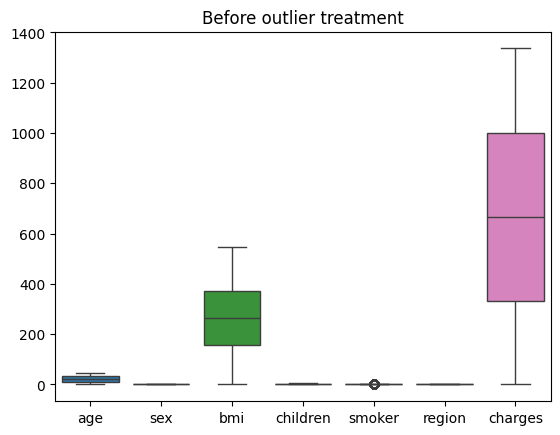

In [ ]:
plt.figure()
sns.boxplot(data=df)
plt.title("Before outlier treatment")
plt.show()

<Figure size 800x400 with 0 Axes>

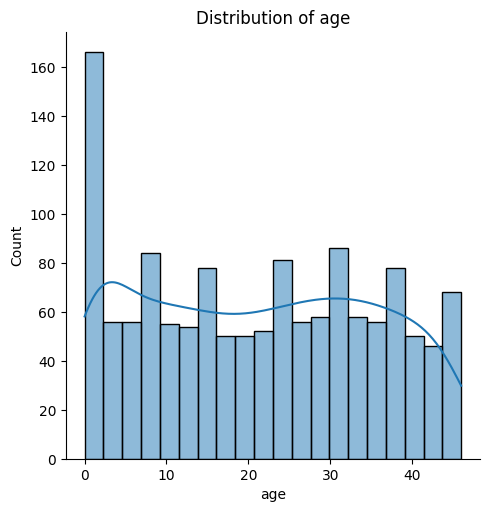

<Figure size 800x400 with 0 Axes>

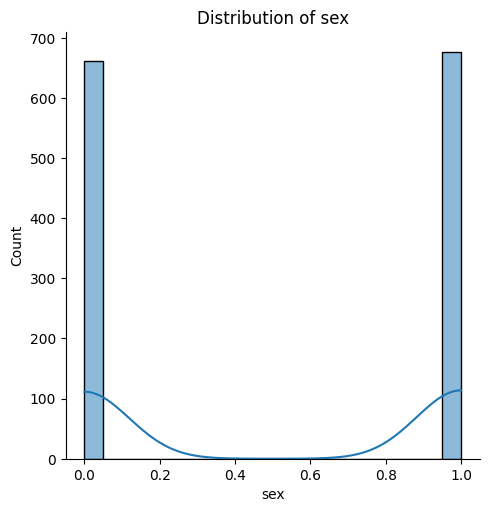

<Figure size 800x400 with 0 Axes>

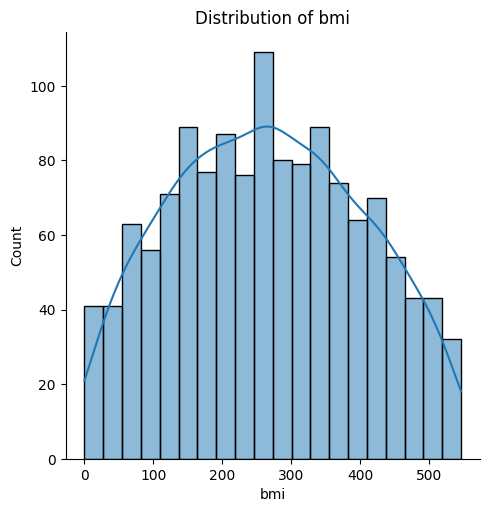

<Figure size 800x400 with 0 Axes>

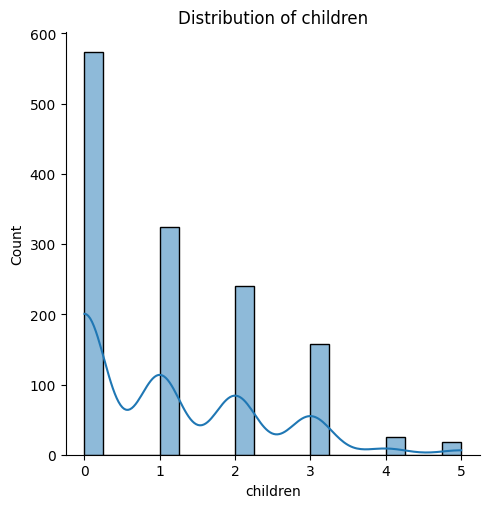

<Figure size 800x400 with 0 Axes>

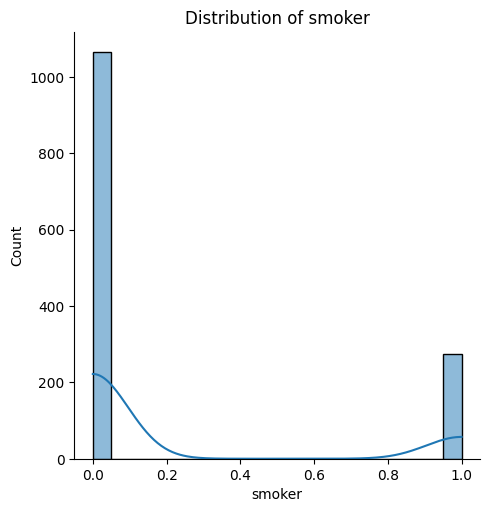

<Figure size 800x400 with 0 Axes>

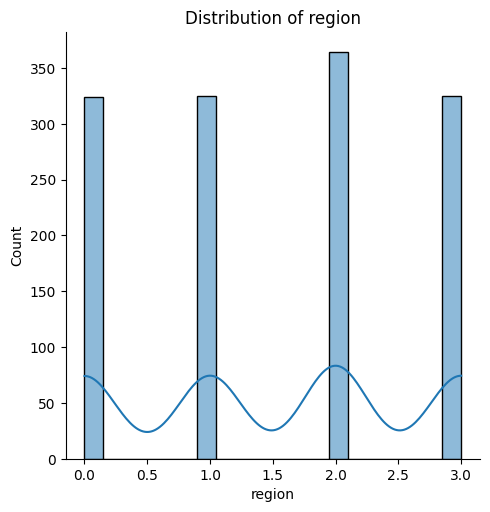

<Figure size 800x400 with 0 Axes>

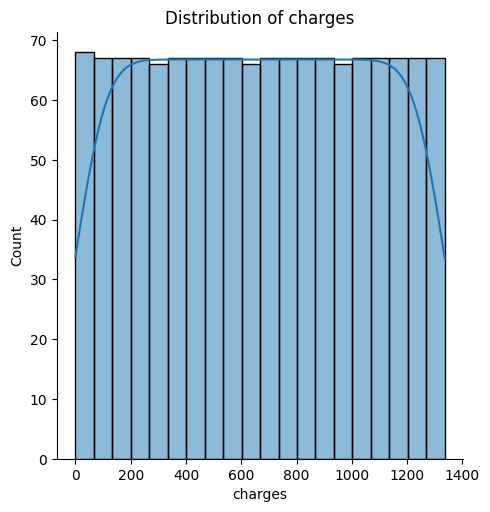

In [ ]:
for column in df.columns:
    plt.figure(figsize=(8, 4))
    sns.displot(df[column], bins=20, kde=True)
    plt.title(f"Distribution of {column}")
    plt.show()

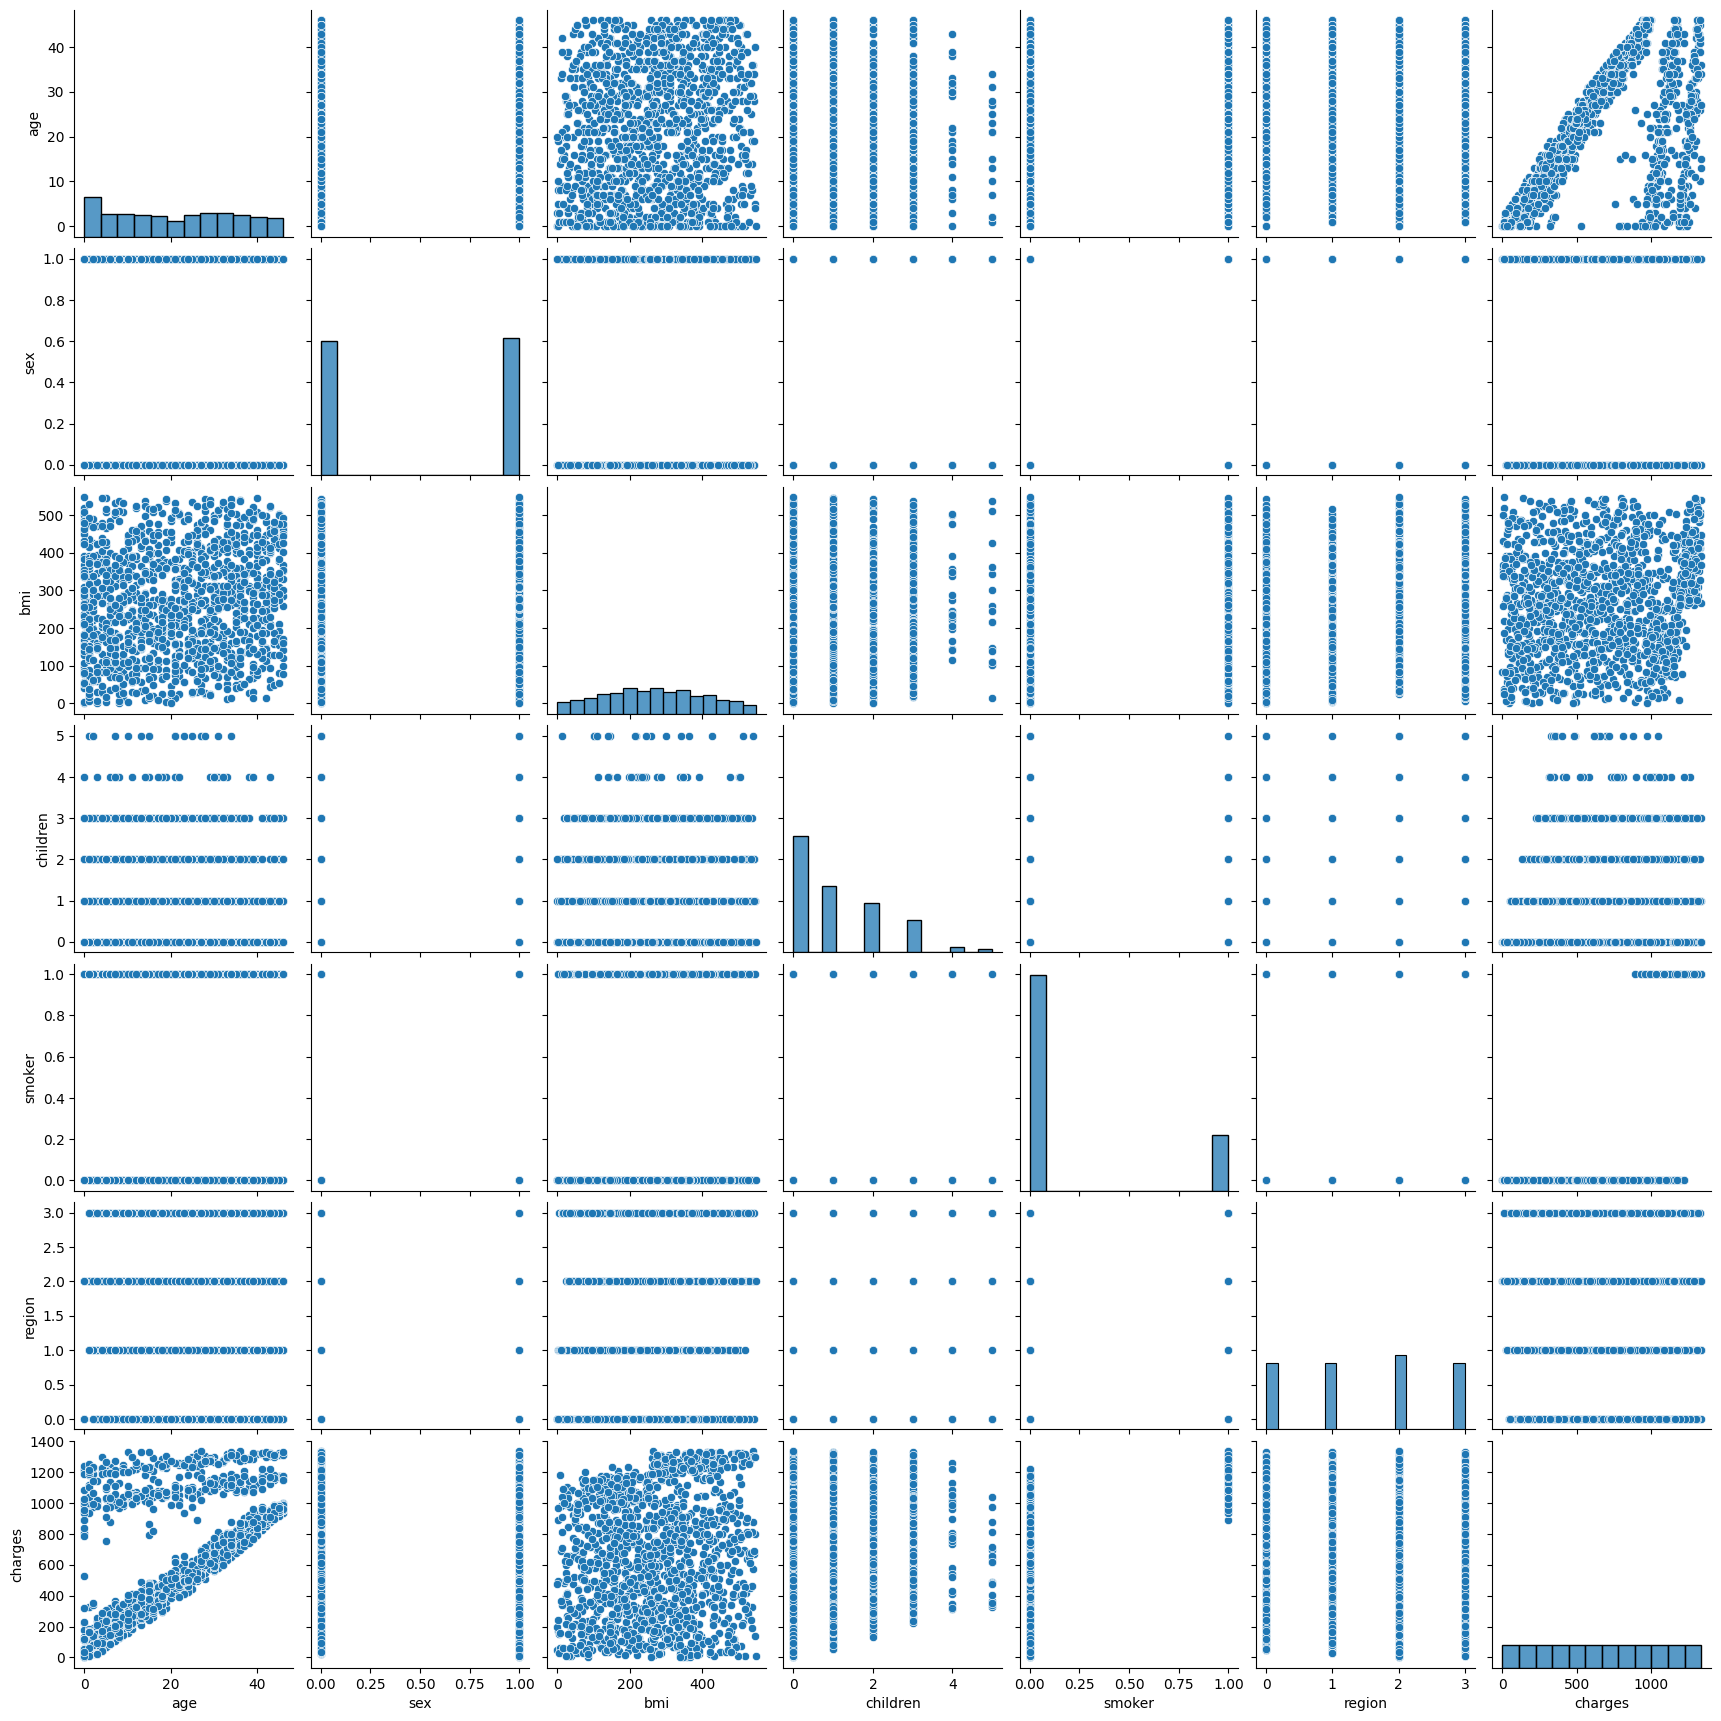

In [ ]:
sns.pairplot(df)
plt.show()

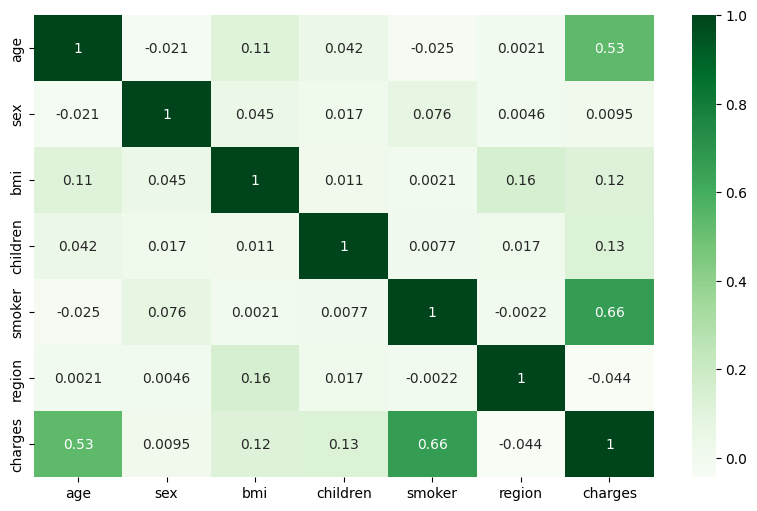

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="Greens")
plt.show()

In [ ]:
x=df.drop('charges',axis=1)
y=df['charges']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
param_grid={
    'n_estimators': [10, 50, 100, 200, 300],
    'criterion': ['squared_error', 'absolute_error']
}
rf=RandomForestRegressor(random_state=42)
grid_search=GridSearchCV(estimator=rf, param_grid=param_grid, cv=5)
grid_search.fit(x_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'criterion': 'squared_error', 'n_estimators': 300}
Best Score: 0.7869713481901129


In [ ]:
grid_search.best_params_

{'criterion': 'squared_error', 'n_estimators': 300}

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=100,criterion="squared_error")
rf.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
y_pred=rf.predict(x_test)
y_pred

array([ 657.05      ,  379.39      , 1164.39      ,  685.93      ,
       1197.64      ,  559.66      ,  101.05      ,  955.24      ,
        391.04      ,  730.34      , 1057.88      ,  516.63      ,
        323.47      , 1300.87      , 1320.65      , 1294.63      ,
        734.18      , 1280.19      ,  638.26      , 1109.5       ,
        357.62      ,  639.9       ,  105.81      ,  134.77      ,
        766.88      ,  787.89      ,  907.14      ,  412.08      ,
        735.34      ,  138.39      ,  545.64      ,  828.28      ,
        123.9       ,  384.99      ,  212.29      ,  686.42      ,
        194.13      ,  554.43      , 1121.76      , 1254.46      ,
        408.1       ,  222.68      ,  824.9       ,  892.55      ,
        385.22      ,  949.63      ,  783.15      ,  344.78      ,
       1273.49      ,  426.45      ,  942.97      ,  146.66333333,
        519.48      ,   57.29      ,  786.99      ,  745.18      ,
        242.23      , 1255.13      ,  835.46      ,  852.29   

In [ ]:
rf.score(x_train,y_train)

0.9682848340166289

In [ ]:
rf.score(x_test,y_test)

0.7945484756720894

# **ROC**

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
y_pred=rf.predict(x_test)
r2=r2_score(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
rmse=np.sqrt(mean_squared_error(y_test, y_pred))
print("R² Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R² Score: 0.7945484756720894
MAE: 86.97825870646766
RMSE: 177.31432104578306


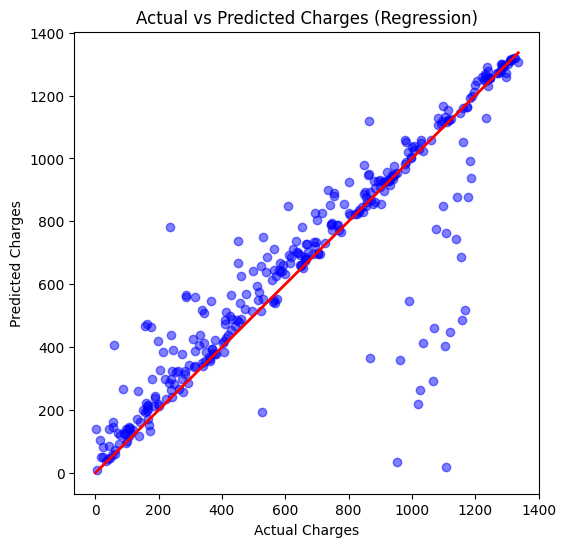

In [ ]:
y_pred=rf.predict(x_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges (Regression)")
plt.show()


# **Confusion Matrix**

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix
bins=[0, 10000, 20000, 100000]
labels=['Low', 'Medium', 'High']
y_test_cat=pd.cut(y_test, bins=bins, labels=labels)
y_pred_cat=pd.cut(y_pred, bins=bins, labels=labels)
cm=confusion_matrix(y_test_cat, y_pred_cat)
print(cm)

[[335]]


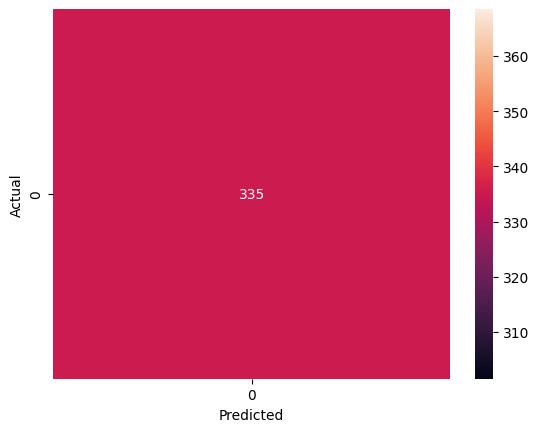

In [ ]:
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
bins=[0, 10000, 20000, 100000]
labels=['Low', 'Medium', 'High']
y_test_cat=pd.cut(y_test, bins=bins, labels=labels)
y_pred_cat=pd.cut(y_pred, bins=bins, labels=labels)
cr=classification_report(y_test_cat, y_pred_cat)
print(cr)

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       335

    accuracy                           1.00       335
   macro avg       1.00      1.00      1.00       335
weighted avg       1.00      1.00      1.00       335



# **Final Prediction**

In [ ]:
age=int(input("Enter age:"))
bmi=float(input("Enter BMI: "))
children=int(input("Enter number of children: "))
sex_input=input("Enter sex (male/female): ").lower()
smoker_input=input("Enter smoker (yes/no): ").lower()
region_input=input("Enter region (northeast/northwest/southeast/southwest): ").lower()
sex=1 if sex_input == 'male' else 0
smoker=1 if smoker_input == 'yes' else 0
region_mapping={'northeast':0, 'northwest':1, 'southeast':2, 'southwest':3}
region=region_mapping[region_input]
predict_value=rf.predict([[age, sex, bmi, children, smoker, region]])
print(f"Predicted insurance charges: {predict_value[0]:.2f}")

Enter age: 32
Enter BMI: 33
Enter number of children: 2
Enter sex (male/female): female
Enter smoker (yes/no): Yes
Enter region (northeast/northwest/southeast/southwest): southeast
Predicted insurance charges: 1098.70
